# Mesh resolution

In [1]:
from lucifex.solver import OptionsPETSc
from lucifex.fdm import AB, CN
from lucifex.sim import run, Simulation
from lucifex.viz import plot_colormap, plot_line
from lucifex.utils import as_index
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

STORE = 1
CELL_TYPE = 'quadrilateral'

def create_simulation(
    Nx,
    Ny,
    cell,
):
    return dns_system_a(
        store_delta=STORE, 
    )(
        Nx=Nx,
        Ny=Ny,
        cell=cell,
        scaling='advective',
        **SYSTEM_A_REFERENCE,
        D_adv=AB(1)@CN,
        D_diff=AB(1)@CN,
        courant_adv=0.5,
        courant_diff=0.5,
        c_stabilization=None,
        c_limits=None,
        c_petsc=OptionsPETSc('gmres', 'ilu'),
        flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
        diagnostic=True,
    )


NxNy_opts = (
    (60, 60), (120, 60), (120, 120), 
    (160, 120), (160, 160), (180, 180),
)
simulations: dict[tuple[int, int], Simulation] = {}

for Nx, Ny in NxNy_opts:
    simulations[(Nx, Ny)] = create_simulation(Nx, Ny, CELL_TYPE)

n_stop = 600
t_stop = 20.0
dt_init = 1e-6
n_init = 10
for NxNy in NxNy_opts:
    sim = simulations[NxNy]
    run(sim, n_stop, t_stop, dt_init=dt_init, n_init=n_init)

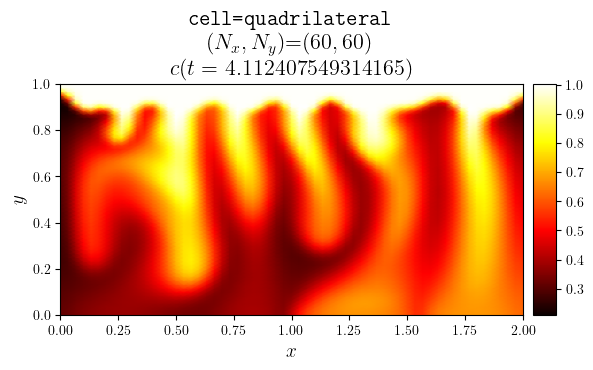

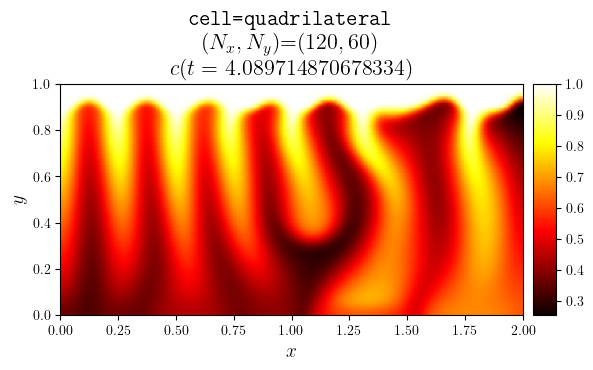

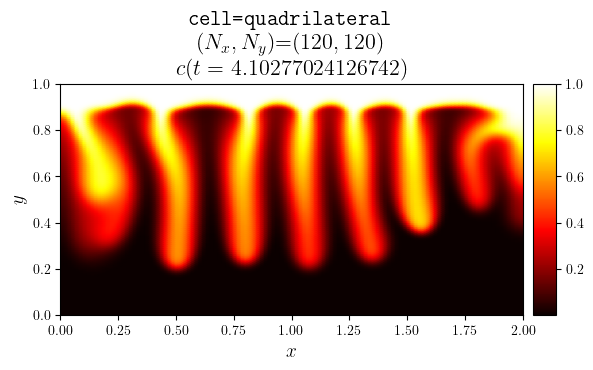

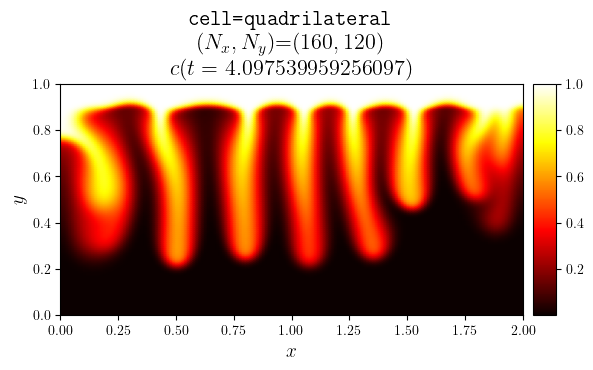

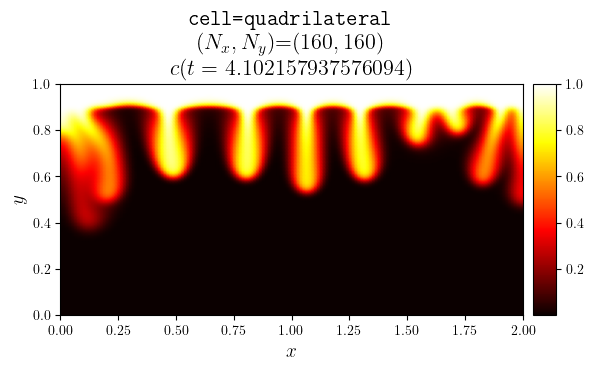

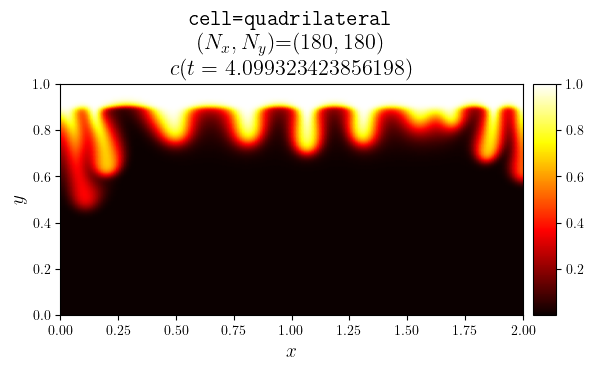

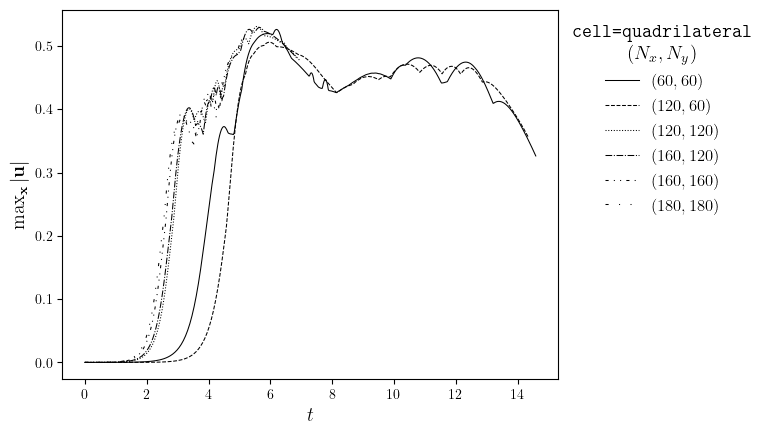

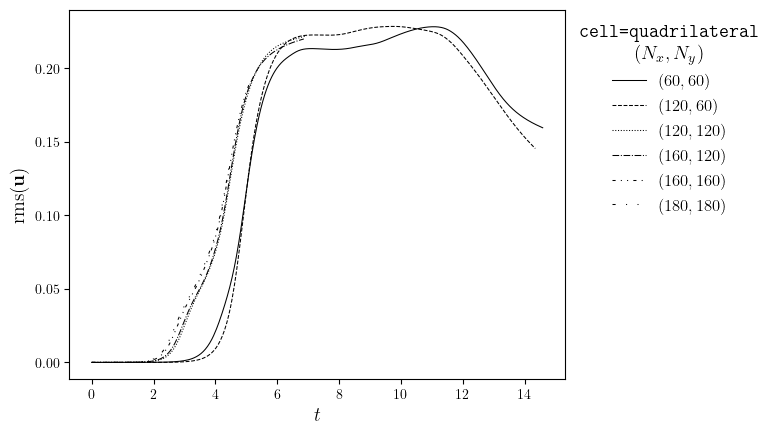

In [2]:
T_TARGET = 4.1

uMax_lines, uRMS_lines, labels = [], [], []
legend_title = f'$\\texttt{{cell={CELL_TYPE}}}$\n $(N_x, N_y)$'

for Nx, Ny in NxNy_opts:
    label = f'$({Nx}, {Ny})$'
    labels.append(label)
    sim = simulations[(Nx, Ny)]
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, T_TARGET)
    cmap_title = f'{legend_title}$=${label}\n$c(t={c.time_series[time_index]})$'
    fig, ax = plot_colormap(c.series[-1], title=cmap_title)

fig, ax = plot_line(
    uMax_lines,
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    legend_labels=labels,
    legend_title=legend_title,
)
fig, ax = plot_line(
    uRMS_lines,
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
    legend_labels=labels,
    legend_title=legend_title,
)